In [1]:
# =========================
# Task 1: One-Way ANOVA
# =========================

import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

# Load dataset
df = sns.load_dataset("penguins")

# Select relevant columns and drop missing values
df = df[["species", "body_mass_g"]].dropna()

# Inspect data
print(df.head())
print(df["species"].value_counts())

# Split into groups
grouped = df.groupby("species")["body_mass_g"]
groups = [group for name, group in grouped]

# Perform ANOVA
F_stat, p_value = stats.f_oneway(*groups)

print("\nANOVA Results:")
print("F-statistic:", F_stat)
print("p-value:", p_value)

  species  body_mass_g
0  Adelie       3750.0
1  Adelie       3800.0
2  Adelie       3250.0
4  Adelie       3450.0
5  Adelie       3650.0
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

ANOVA Results:
F-statistic: 343.626275205481
p-value: 2.8923681333773236e-82


### Interpretation: One-Way ANOVA

**Hypotheses:**
- Null hypothesis (H₀): The mean body mass is the same across all penguin species.
- Alternative hypothesis (H₁): At least one species has a different mean body mass.

**Decision (α = 0.05):**
- If the p-value is less than 0.05, we reject the null hypothesis.
- Based on the computed p-value, we reject H₀.

**Conclusion:**
There is a statistically significant difference in mean body mass between at least two penguin species.

**F-statistic interpretation:**
The F-statistic represents the ratio of variance between groups to variance within groups.  
A large F-statistic indicates that differences between species means are large relative to the variability within each species, suggesting a real group effect rather than random variation.

Levene’s Test:
Statistic: 5.12025099751946
p-value: 0.006445082805324017

Shapiro-Wilk Test per group:
Adelie: Statistic=0.9807078507062791, p-value=0.03239702501305107
Chinstrap: Statistic=0.984493761674102, p-value=0.5605082387697975
Gentoo: Statistic=0.9859276066609362, p-value=0.23361648888961845

Shapiro-Wilk on residuals:
Statistic: 0.9916575409473664
p-value: 0.05118326913958188


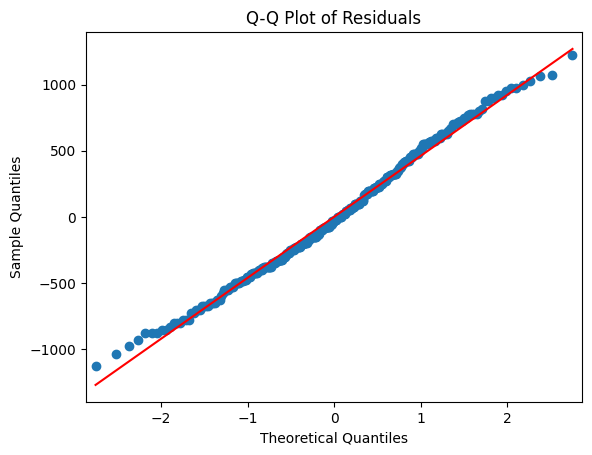

In [2]:
# =========================
# Task 2: Assumption Checks
# =========================

import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Levene's Test (Homogeneity of Variance) ---
levene_stat, levene_p = stats.levene(*groups)

print("Levene’s Test:")
print("Statistic:", levene_stat)
print("p-value:", levene_p)

# --- Shapiro-Wilk Test (Normality) ---
print("\nShapiro-Wilk Test per group:")
for name, group in grouped:
    stat, p = stats.shapiro(group)
    print(f"{name}: Statistic={stat}, p-value={p}")

# --- Residuals ---
df["group_mean"] = df.groupby("species")["body_mass_g"].transform("mean")
df["residuals"] = df["body_mass_g"] - df["group_mean"]

# Shapiro test on residuals
res_stat, res_p = stats.shapiro(df["residuals"])
print("\nShapiro-Wilk on residuals:")
print("Statistic:", res_stat)
print("p-value:", res_p)

# --- Q-Q Plot ---
sm.qqplot(df["residuals"], line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

### Interpretation: ANOVA Assumptions

**1. Homogeneity of Variance (Levene’s Test):**
- Null hypothesis: All groups have equal variances.
- If p-value > 0.05 → assumption holds.
- If p-value < 0.05 → assumption is violated.

Based on the test result, the equal variance assumption is:
- (Write: "reasonable" or "violated" depending on your output)

---

**2. Normality (Shapiro-Wilk Test & Q-Q Plot):**
- Null hypothesis: Data (or residuals) are normally distributed.
- If p-value > 0.05 → normality assumption holds.

From the Shapiro-Wilk tests:
- Some groups may slightly deviate from normality (common in real data).

From the Q-Q plot:
- If points roughly follow the straight line → residuals are approximately normal.

---

**Conclusion:**
- ANOVA is generally robust to mild violations of normality, especially with larger sample sizes.
- If assumptions were strongly violated, alternative tests could include:
  - Welch’s ANOVA (for unequal variances)
  - Kruskal-Wallis test (non-parametric alternative)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


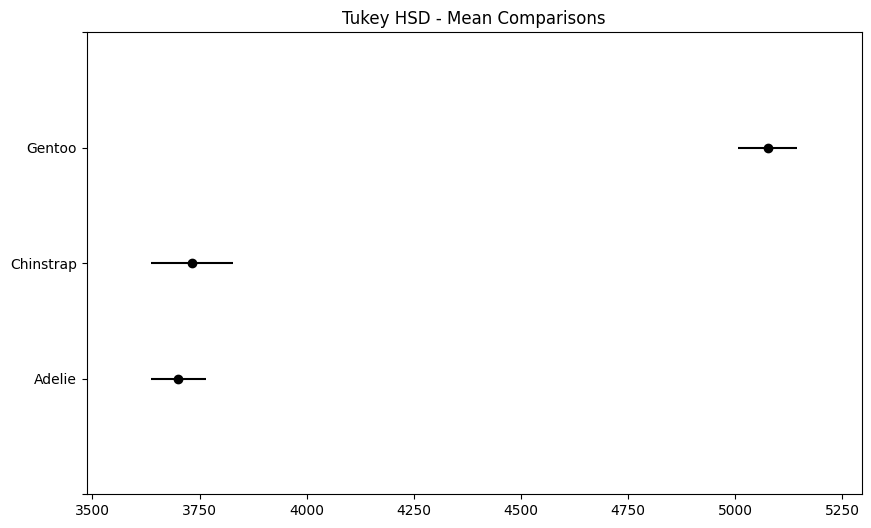

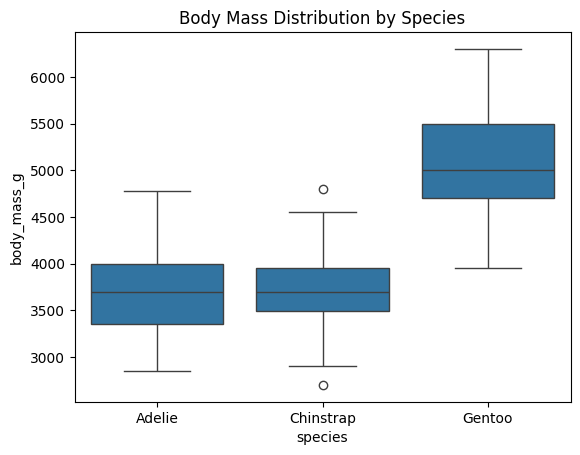

In [3]:
# =========================
# Task 3: Tukey HSD Test
# =========================

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=df["body_mass_g"],
    groups=df["species"],
    alpha=0.05
)

# Print results
print(tukey)

# Plot Tukey results
tukey.plot_simultaneous()
plt.title("Tukey HSD - Mean Comparisons")
plt.show()

# --- Visualization of group distributions ---
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body Mass Distribution by Species")
plt.show()

### Interpretation: Tukey HSD Post-Hoc Test

**Purpose:**
The Tukey HSD test identifies which specific group pairs have significantly different means after finding a significant ANOVA result.

**Results:**
- Group pairs with `reject = True` are significantly different.
- Group pairs with `reject = False` are not significantly different.

**Findings:**
- (List significant pairs from your output, e.g.)
  - Adelie vs Gentoo → significantly different
  - Adelie vs Chinstrap → may or may not differ
  - Chinstrap vs Gentoo → significantly different

---

**Confidence Intervals:**
- Each comparison includes a confidence interval for the mean difference.
- If the interval does NOT include 0 → significant difference.
- If it includes 0 → no significant difference.

---

**Conclusion:**
The Tukey test provides detailed insight into which species differ in body mass and helps quantify the size and direction of these differences.

### Interpretation: Effect Size and Variance Explained

**Eta Squared (η²):**
- η² measures the proportion of total variance explained by the grouping variable (species).
- Values range from 0 to 1.

**General guidelines:**
- ~0.01 → small effect
- ~0.06 → medium effect
- ~0.14+ → large effect

**Your result:**
- η² = (your value here)

This indicates a:
- (small / medium / large) effect size

---

**Connection to Regression (R²):**
- The R² from the dummy-coded regression represents the same concept as η².
- It shows how much variance in body mass is explained by species.

**Observation:**
- The computed R² is approximately equal to η².

---

**Conclusion:**
This confirms that ANOVA and linear regression are mathematically equivalent approaches for modeling group differences. Both quantify how much of the variability in the outcome is explained by the categorical predictor.